# HW Tool

## 1. `shap.plots.beeswarm` нормального человека (6 баллов)

Как вы могли видеть, у встроенного beeswarm plot`а есть несколько недостатков:
- нет информации о том, какие именно значения категориальных признаков в какую сторону толкают предсказания модели
- иногда серые точки (пропущенные значения) прячутся за точками другого цвета -> их не видно (см. rooms_num на графике с семинара)
- иногда раскраска бывает некорректной (потому что она раскрашивает по абсолютным значениям)

Вам предлагается реализовать свою версию shap.plots.beeswarm, которая исправляет эти недостатки.


Итак, требуется написать функцию, которая принимает на вход shap_values и все необходимое и строит по этим данным beeswarm plot
    без вышеперечисленных недостатков, а именно:
- теперь все уникальные значения кат. фич становятся как бы отдельными фичами, по ним видны shap_values (см. пример)
    - чтобы не захламлять ваш график редковстречающимися категориями, принимайте на вход параметр, чтобы контролировать это
    - такие фичи должны быть покрашены в особый цвет, чтобы отличаться от числовых
- точки, отвечающие за наны, должны быть хорошо видны на фоне остальных и не перекрывать их
- раскраска должна адекватно красить ваши точки
    - можно выкидывать выбросы перед покраской
    - можно логарифмировать значения
    - можно красить по квантилям, а не по абсолютным значениям
    - лучше всего красятся равномерное и нормальное распределение

**Обязательно:**
- docstring
- комменты к непонятным кускам кода - что там происходит
- принимайте на вход кол-во фич, которые вы отображаете на графике
- принимайте на вход размер фигуры
- нарисуйте вертикальную линию, обозначающую 0
- сортируйте признаки по среднему модулю shap_values
- используйте stripplot (или аналоги) с jitter`ом, а не swarmplot
- принимайте на вход кол-во точек которое будете отрисовывать (500-3000 = норм)
    - если для какого-то значения кат фичи точек меньше, чем вы задали, рисуйте сколько есть

**!**
Если на вход подана слишком большая выборка, вы можете под капотом сэмплить из нее какое-то адекватное кол-во точек и отрисовывать их.
Однако, раскраску и контроль за отрисовкой категорий лучше базировать на всей выборке, поданной на вход.


Ниже приведен пример. Не меняйте код, предшествующий примеру. Вы не обязаны повторять пример точь-в-точь, это ориентир. Не удаляйте пример.

Удачи!

In [1]:
from typing import List, Tuple

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import lightgbm as lgb


df = pd.read_parquet("train_sber.parquet")
features = df.columns.drop(["timestamp", "result_price", "result_price_bin"])

model = lgb.Booster(model_file="model.lgb")
shap_values = model.predict(df[features], pred_contrib=True)

"""
Учтите, что если вы считаете shap_values через LightGBM,
    shap_values - np.array of shape (N, F + 1), где последний столбец - константа = среднее предсказание для всех объектов
"""
print("features shape:", features.shape, "shap_values shape:", shap_values.shape)
df.head(3)

features shape: (36,) shap_values shape: (27232, 37)


,district_area,road_distance_1,road_distance_2,year_of_construction,bulvar_ring_km,bus_station_distance,cafe_count,fitness_center_distance,floor,district_population,...,public_transport_station_distance,sadovoe_km,base_school_distance,sport_count,state,district_name,timestamp,malls_count,railway_station_distance,result_price_bin
0,6407578.100,1.422391,3.830951,NaN,13.675657,24.292406,152,0.485841,4.0,86206,...,3.299822,13.100618,0.177975,52,NaN,Bibirevo,2011-08-20,52,14.231961,False
1,9589336.912,2.887377,3.103996,NaN,8.132640,5.706113,177,0.668364,3.0,76284,...,0.783160,6.444333,0.273345,66,NaN,Nagatinskij Zaton,2011-08-23,40,9.242586,False
2,4808269.831,0.647250,2.927487,NaN,8.054252,6.710302,122,0.733101,2.0,101982,...,3.945073,6.963403,0.158072,67,NaN,Tekstil'shhiki,2011-08-27,35,9.540544,False


In [2]:
def my_beeswarm(
    shap_values: np.ndarray,
    df: pd.DataFrame,
    features: List[str],
    n_swarms: int,
    figsize: Tuple[int, int] = (13, 6),
    sample_size: int = 1000,
    random_state: int = 42,
):
    """
    Draws a beeswarm plot for SHAP values with point colored based on feature values.
    Sorts features by their contribution (mean absolute SHAP value) and orders corresponding
    strips from top to bottom.

    Numerical and categorical features are inferred automatically,
    numerical features shap values are colored by their original values,
    categorical features are colored uniformly.

    Parameters
    ---
        shap_values: np.ndarray
            Array of SHAP values of shape (N, F+1), N - number of samples, F - number of features.
            The last column is the model mean prediction.
        df: pd.DataFrame
            Original dataframe
        features: List[str]
            List of names of shap values columns (excluding the last column). Must match
            the length of the shap_values array, every feature must be present in the DataFrame.
        n_swarms: int
            Number of strips to plot. Will display n_swarms most important features.
        figsize: Tuple[int, int], optional
            Figure size to be passed to plt.subplots.
        sample_size: int, optional
            Number of points randomly sampled from the original dataset for plotting.
        random_state: int, optional
            Seed for reproducibility.
    """
    rng = np.random.RandomState(random_state)
    ids = rng.choice(len(df), size=sample_size, replace=False)
    df_sample = df.iloc[ids]
    shap_sample = shap_values[ids]

    shap_values_df = pd.DataFrame(
        shap_sample[:, :-1],
        columns=features,
        index=df_sample.index,  # to make .loc return correct entries
    )
    feature_set = set(features)

    cat_features = list(
        filter(
            lambda x: x in feature_set,
            df_sample.select_dtypes(exclude=["number"]).columns,
        )
    )

    num_features = list(
        filter(
            lambda x: x in feature_set,
            df_sample.select_dtypes(include=["number"]).columns,
        )
    )

    # we will store every stripe data in this list
    # (feature name, shap_values, score, is_categorical)
    # for categorical features, we will treat each unique value as its own "feature"
    # and shap_values will be the values of a single category
    swarms: List[Tuple[str, np.ndarray, float, int]] = []

    for feature in num_features:
        swarms.append(
            (
                feature,
                shap_values_df[feature].values,
                np.mean(np.abs(shap_values_df[feature].values)),
                False,
            )
        )

    for feature in cat_features:
        unique_vals = df_sample[feature].unique()
        for value in unique_vals:
            mask = df_sample[feature] == value

            # for each distinct category, take its shap values
            vals = shap_values_df.loc[mask, feature].values

            # score is calculated includes zero for samples of different categories
            # this is done because categorical features tend to have large shap values
            score = np.mean(np.abs(shap_values_df[feature] * mask))
            swarms.append(
                (
                    f"{feature}_{value}",
                    vals,
                    score,
                    True,
                )
            )

    # take n_swarms best features by score
    swarms = sorted(swarms, key=lambda x: x[2], reverse=True)[:n_swarms]

    fig, ax = plt.subplots(figsize=figsize)

    y_ticks = []
    y_pos = 0

    for name, shap_vals, _, is_categorical in reversed(swarms):
        y_ticks.append(name)
        n_points = len(shap_vals)

        # add noise to y-coordinates to avoid overlapping points
        jitter = rng.normal(0, 0.1, size=n_points)

        # for nan values, reduce jitter to prevent them from overlapping with other points
        if name in num_features:
            na_mask = np.isnan(df_sample[name].values)
            jitter[na_mask] *= 0.25

        y_coords = np.full(n_points, y_pos) + jitter

        if is_categorical:
            colors = ["green"] * n_points
        else:
            # to avoid bias towards outliers, take 0.1 and 0.9 quantiles
            feature_vals = df_sample[name].values
            vmin = np.nanquantile(feature_vals, 0.1)
            vmax = np.nanquantile(feature_vals, 0.9)

            norm = plt.Normalize(vmin=vmin, vmax=vmax)
            cmap = plt.cm.coolwarm
            colors = cmap(norm(feature_vals))
            colors[:, -1] = 0.7  # display NaNs as black points

        ax.scatter(shap_vals, y_coords, c=colors, s=10, edgecolor="none")
        y_pos += 1

    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    for y in range(len(y_ticks)):
        ax.axhline(y=y, color="gray", linestyle="--", alpha=0.5)

    ax.set_yticks(range(len(y_ticks)))
    ax.set_yticklabels(y_ticks)
    ax.set_xlabel("Contribution")
    ax.set_ylabel("Feature")
    ax.set_title("SHAP Beeswarm Plot")

    if num_features:  # works if there is at least one scatterplot with coloring
        sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("Relative feature value")

    plt.tight_layout()
    plt.show()


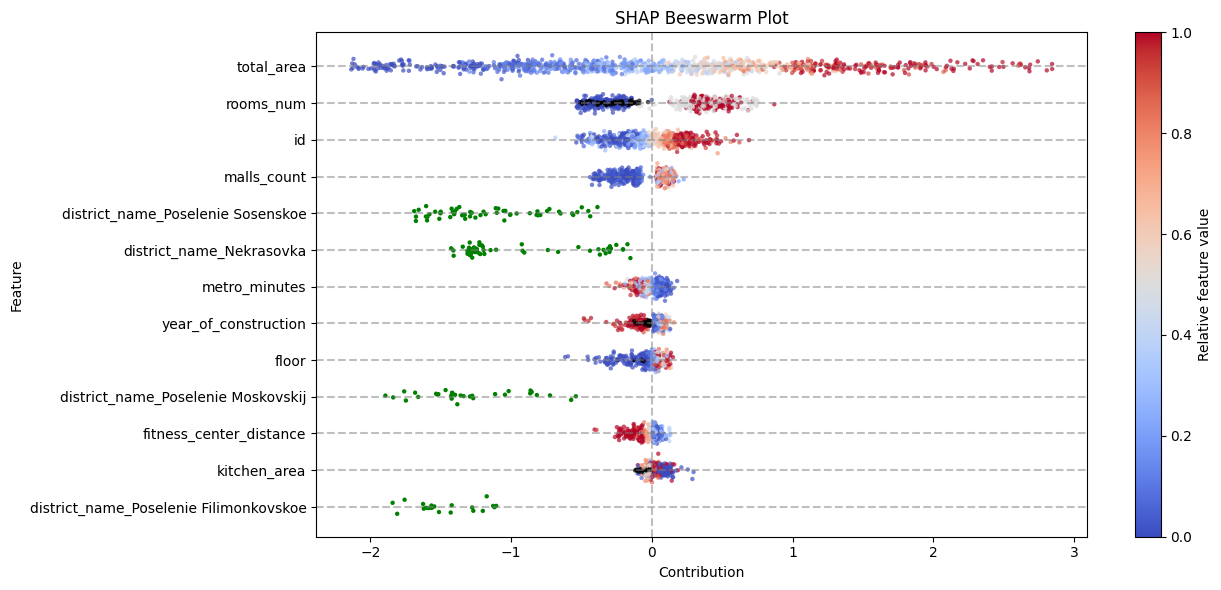

In [ ]:
my_beeswarm(
    shap_values,
    df,
    features,
    n_swarms=13,
    figsize=(13, 6),
)

Пример ниже. Не удаляйте пример!

CPU times: total: 1.61 s
Wall time: 1.61 s


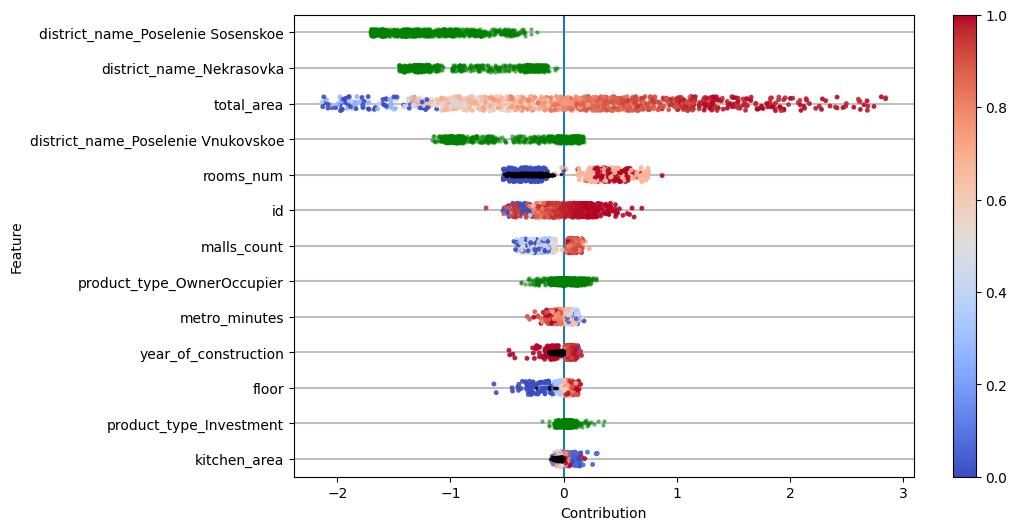

In [ ]:
%%time
from utils import shap_beeswarm

shap_beeswarm(
    model,
    df,
    features,
    cat_feature_threshold=0.001,
    shap_values=shap_values,
    top_k=13,
    figsize=(10, 6),
    dots=1000,
)

## 2. Логирование градиентов при обучении (4 балла)

**Задача:** хотим для каждого объекта для каждого дерева получить gi - производную лосса!
Чтобы:
- нарисовать карту объект-дерево
- поизучать 2D-представления
- призадуматься...

**Как:** придумайте способ! Нужно в процессе обучения сохранять градиенты LogLoss`а объектов на каждом дереве, после чего продемонстрировать собранные градиенты с помощью sns.clustermap. 

Ниже пример. Не удаляйте пример!

In [ ]:
def get_split(df, val_size=0.33):
    train_idx = np.random.choice(
        df.index, size=int(df.shape[0] * (1 - val_size)), replace=False
    )
    val_idx = np.setdiff1d(df.index, train_idx)
    return df.loc[train_idx].reset_index(drop=True), df.loc[val_idx].reset_index(
        drop=True
    )


tr, val = get_split(df, val_size=0.23)
lgb_tr = lgb.Dataset(tr[features], tr.result_price_bin)

In [5]:
import sympy as sp
from IPython.display import display

x = sp.symbols("x")
y = sp.symbols("y")
p = 1 / (1 + sp.exp(-x))

logloss = - y * sp.log(p) - (1 - y) * sp.log(1 - p)

print("LogLoss:")
display(logloss)

grad = sp.diff(logloss, x).simplify()
print("Gradient:")
display(grad)

LogLoss:


-y*log(1/(1 + exp(-x))) - (1 - y)*log(1 - 1/(1 + exp(-x)))

Gradient:


(-y + (1 - y)*exp(x))/(exp(x) + 1)

In [ ]:
def log_loss_grad(pred: np.ndarray, target: np.ndarray) -> np.ndarray:
    """
    Calculates the gradient of logistic loss function for every pair (pred, target)
    in the input arrays.

    Parameters
    ---
        pred: np.ndarray
            Array of model predictions, shape (N,)
        target: np.ndarray
            Array of true values, shape (N,)

    Returns
    ---
        np.ndarray
            Array of gradients, shape (N,)
    """
    return (-target + (1 - target) * np.exp(pred)) / (1 + np.exp(pred))


def get_gradients(model: lgb.Booster, x: pd.DataFrame, y: pd.Series) -> np.ndarray:
    """
    Calculates gradients of the logistic loss function with respect to model raw predictions
    for every iteration.

    Parameters
    ---
        model: lgb.Booster
            LightGBM model
        x: pd.DataFrame
            DataFrame of features, shape (N, F)
        y: pd.Series
            Series of true values, shape (N,)

    Returns
    ---
        np.ndarray
            Array of gradients, shape (N, T), where T is the number of iterations
            in the model.
    """
    y = y.values.astype(np.float32)
    return np.stack(
        [
            log_loss_grad(
                model.predict(x, start_iteration=0, num_iteration=i, raw_score=True), y
            )
            for i in range(1, model.num_trees() + 1)
        ],
        axis=-1,
    )


grads = get_gradients(model, val[features], val.result_price_bin)

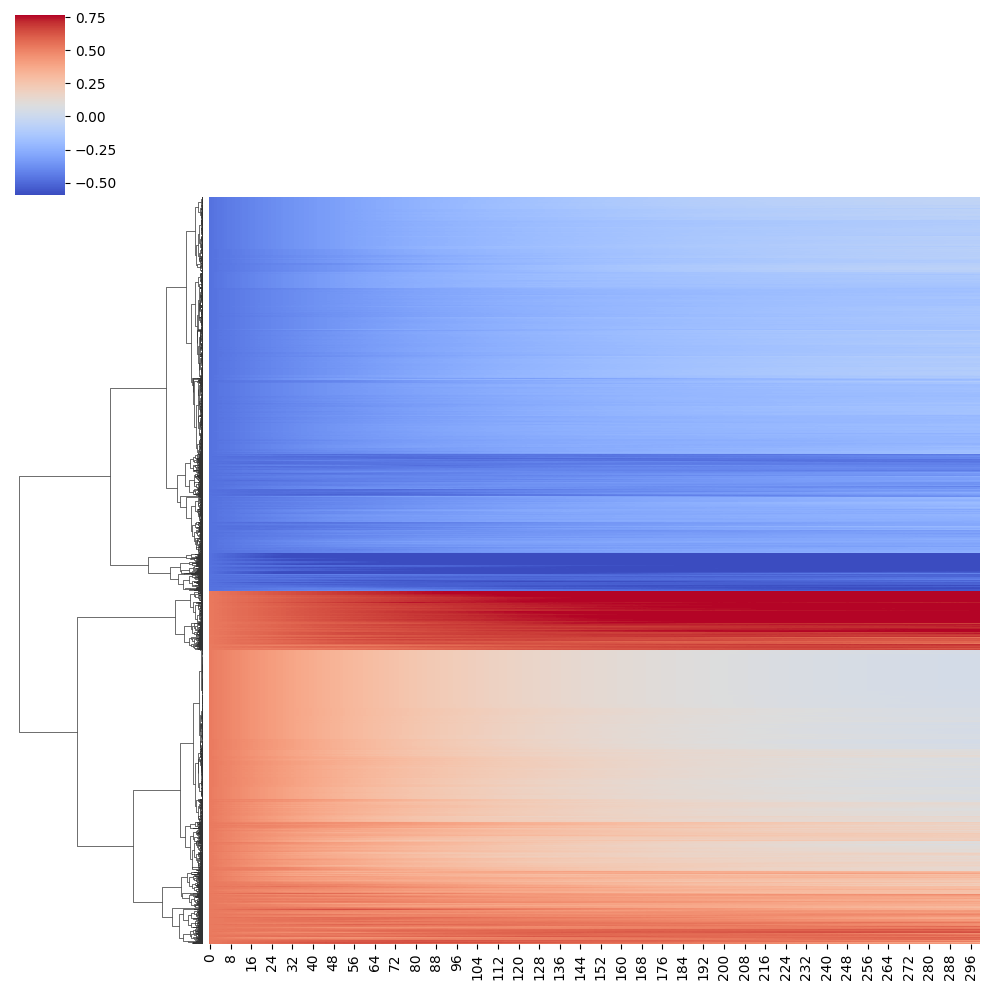

In [7]:
sns.clustermap(
    grads, col_cluster=False, robust=True, yticklabels=False, cmap="coolwarm"
)

Пример. Не удаляйте пример!

In [ ]:
def get_split(df, val_size=0.33):
    train_idx = np.random.choice(
        df.index, size=int(df.shape[0] * (1 - val_size)), replace=False
    )
    val_idx = np.setdiff1d(df.index, train_idx)
    return df.loc[train_idx].reset_index(drop=True), df.loc[val_idx].reset_index(
        drop=True
    )


tr, val = get_split(df, val_size=0.23)
lgb_tr = lgb.Dataset(tr[features], tr.result_price_bin)

grads = somehow_get_grads()
grads.shape

(100, 20968)

CPU times: total: 1min 17s
Wall time: 1min 17s


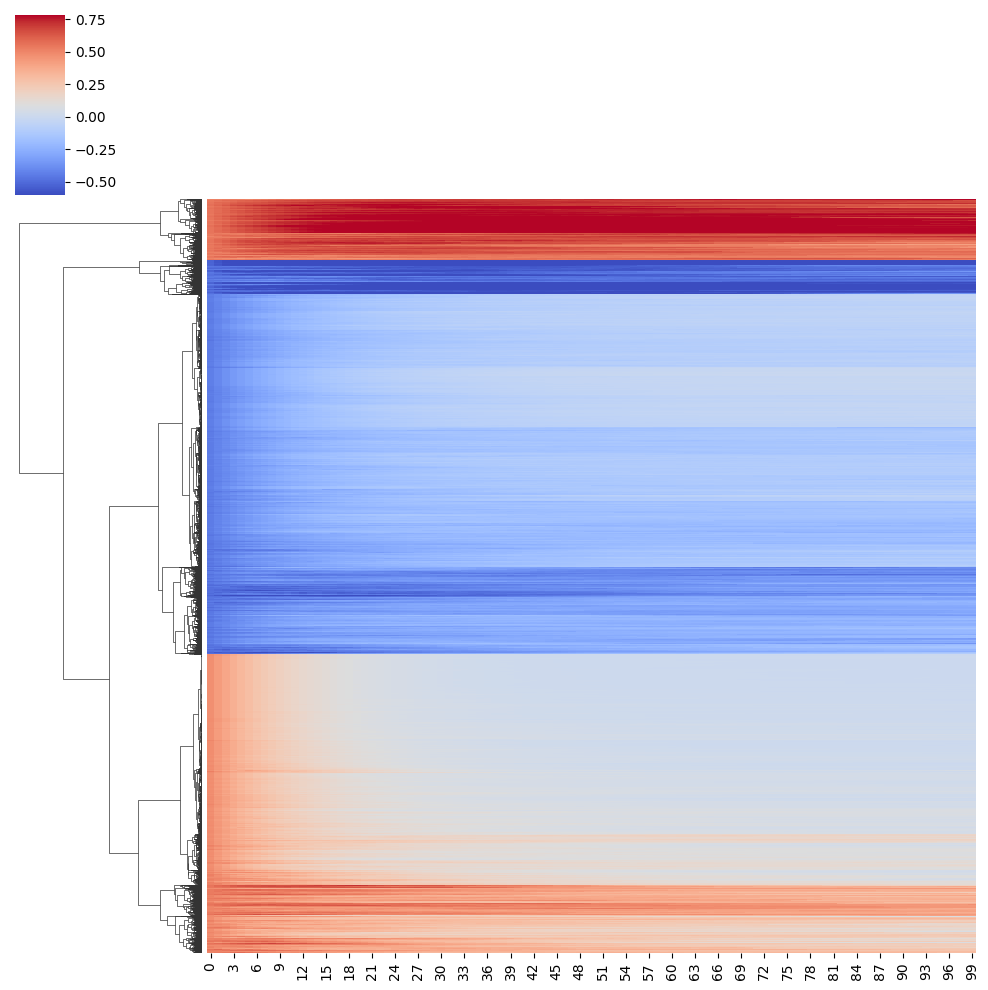

In [ ]:
%%time
import seaborn as sns

# предварительно установите fastcluster: pip install fastcluster, иначе считаться будет долго
sns.clustermap(
    grads.T, col_cluster=False, robust=True, yticklabels=False, cmap="coolwarm"
)

## 3. Автоматическое создание весов для бинарной классификации (5 баллов)

В этом блоке ваша цель - написать функцию, которая генерирует вектор весов для объектов обучающей выборки следующим образом:
1) на вход подается таргет-колонка и произвольная колонка
2) если колонка числовая, бьем ее на бины (кол-во бинов `bins` принимаем на вход. берем небольшое, около 7-13)
    - если в колонке < `bins` уникальных, бить не надо 
3) если колонка категориальная, тоже бьем ее на бины
    - если уникальных значений <= `bins`, то за бины считаем уникальные значения категории
    - если уникальных значений >  `bins`, то выбираем `bins` - 1 самых популярных категорий у объектов класса 1
    - не попавшие в топ самых популярных категории запихиваем в бин 'other'

4) проходимся по всем бинам, присваивая всем объектам класса 1, попавшим в бин, вес n_0_in_bin / n_1_in_bin,
       если объектов класса 0, попавших в этот бин, достаточное кол-во (принимайте на вход, зависит от задачи)

5) всем объектам класса 0 присваиваем вес, равный единице

Такая схема на практике работает лучше, чем обычный `scale_pos_weight` параметр в LightGBM и его аналоги, если разумно выбирать
    вспомогательную колонку. Подумайте, как именно нужно выбирать такую колонку. Ответ писать не обязательно, но можно :)

**Обязательно:**
Найдите способ продемонстрировать визуализацией, что ваша функция работает корректно!

In [ ]:
def get_bins(col: pd.Series, n_bins: int) -> pd.Series:
    """
    Performs binning of a column into n_bins bins.

    If col is categorical, it will unite least frequent categories into one bin
    up to n_bins categories.

    If col is numeric, it will bin them into n_bins uniform quantiles.

    Parameters
    ---
        col: pd.Series
            Column to be binned.
        n_bins: int
            Number of bins to create.

    Returns
    ---
        pd.Series
            Binned column.
    """
    unique_values, counts = np.unique(col, return_counts=True)
    # change nothing if there are less than n_bins unique values
    if len(unique_values) <= n_bins:
        mapping = {value: i for i, value in enumerate(unique_values)}
        return col.map(mapping)

    # for numeric columns, binning is done by quantiles
    if col.dtype.kind in "iuf":
        quantiles = np.linspace(0, 1, n_bins + 1)
        bins = col.quantile(quantiles)
        intervals = pd.cut(col, bins=bins, include_lowest=True)

        mapping = {interval: i for i, interval in enumerate(intervals.cat.categories)}

        return intervals.map(mapping)

    # for categorical columns, we will unite least frequent categories
    # into one bin up to n_bins categories
    ids = np.argsort(counts)[::-1]
    unique_values = unique_values[ids]
    counts = counts[ids]
    mapping = {value: min(i, n_bins - 1) for i, value in enumerate(unique_values)}

    return col.map(mapping)


def get_weight_by_bins(
    col: pd.Series,
    target: pd.Series,
    n_bins: int = 10,
    min_negative_samples_bin: int = 100,
) -> np.ndarray:
    """
    Creates a weight vector for a dataset based on binning of a given column.
    The column is binned into n_bins bins, and the weight for each bin is
    calculated as the ratio of negative samples to positive samples in that bin.

    Parameters
    ---
        col: pd.Series
            Column, with respect to which the weights are calculated.
        target: pd.Series
            Target column for weight calculation.
        n_bins: int
            Number of bins to create from col.
        min_negative_samples_bin: int
            Minimum number of negative samples in a bin to assign a them.
            If in some bin there are less than min_negative_samples_bin negative samples,
            the weight for that bin is set to 1, otherwise it is set to the n0_bin / n1_bin ratio.

    Returns
    ---
        np.ndarray
            Weight vector of the same length as col.
    """
    bins = get_bins(col, n_bins).astype(np.int32)

    df = pd.DataFrame({"bins": bins, "target": target})

    # calculate negative class counts and ratios
    weights_mapping = df.groupby("bins", observed=True).agg(
        n0=("target", lambda x: np.sum(x == 0)),
        weight=("target", lambda x: np.sum(x == 0) / (np.sum(x == 1) + 1e-4)),
    )

    # recompute weight for bins with less than min_negative_samples_bin negative samples
    weights_mapping["weight"] = weights_mapping["weight"].where(
        weights_mapping["n0"] >= min_negative_samples_bin, 1
    )

    weights = np.ones_like(bins, dtype=np.float32)
    weights[target == 1] = bins[target == 1].map(weights_mapping["weight"])

    return weights

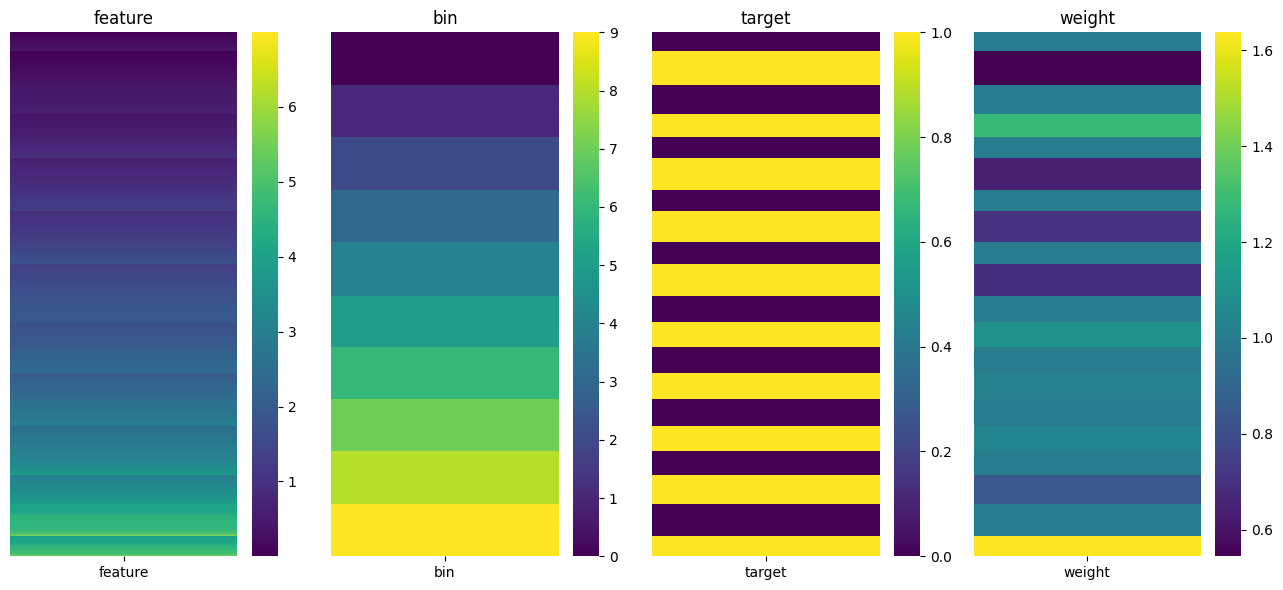

In [28]:
column = "road_distance_1"
target = df.result_price_bin.astype(np.int32)

features = df[column]

bins = get_bins(features, 10)

weights = get_weight_by_bins(
    features,
    target,
    n_bins=10,
    min_negative_samples_bin=100,
)

data = pd.DataFrame(
    {
        "feature": features,
        "bin": bins.astype(np.int32),
        "target": target,
        "weight": weights,
    }
)
data.sort_values(by=["bin", "target"], inplace=True)


n_cols = data.shape[1]
fig, axes = plt.subplots(1, n_cols, figsize=(13, 6))
axes = axes.flatten()


for ax, col in zip(axes, data.columns):
    sns.heatmap(data[[col]], ax=ax, cmap="viridis", yticklabels=False)

    ax.set_title(col)

plt.tight_layout()
plt.show()